In [1]:
# importar librerias
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Definir las funciones de activación y entrenamiento
# Función de activación (escalón)

def linear_function(x):
    return x

# Función para hacer predicciones(output)


def adaline_predict(X, weights):
    return linear_function(np.dot(X, weights[1:]) + 0*weights[0])


In [3]:

# Algoritmo del Perceptrón


def adaline_train(X, y, learning_rate, epochs):
    # Inicializar los pesos (uno más para el bias)
    weights = np.random.rand(X.shape[1] + 1)
    # vector de error
    errors = []

    # Entrenamiento
    for _ in range(epochs):
        total_error = 0
        for xi, target in zip(X, y):
            # Calcular la salida (predicción)
            # step_function(np.dot(xi, weights[1:]) + weights[0])
            output = adaline_predict(xi, weights)
            # Calcular error absoluto
            error = (target - output)**2
            total_error += abs(error)
            # Actualizar los pesos
            update = 2*learning_rate * (target - output)
            weights[1:] += update * xi
            weights[0] += update
        errors.append(total_error)
    return weights, errors

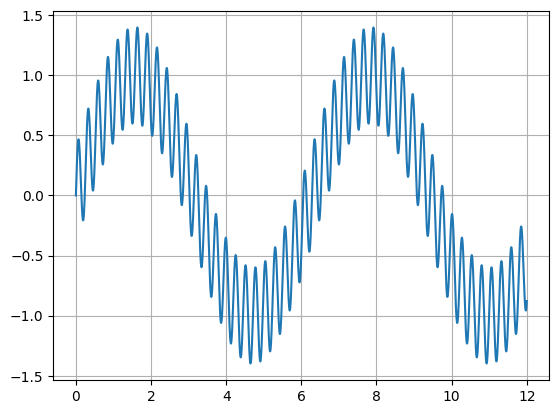

In [4]:

# Preparar los datos de entrada y salida
# Datos de entrada para el filtro adaptativo
# señal con ruido
n_samples = 5000
t = np.linspace(0, 12, n_samples)
# np.random.normal(0, 0.4, n_samples) #0.4*np.sin(24*t)
noise = 0.4*np.sin(24*t)
X = np.sin(t)+noise
plt.plot(t, X)
plt.grid()



Text(0, 0.5, 'Amplitud de la señal')

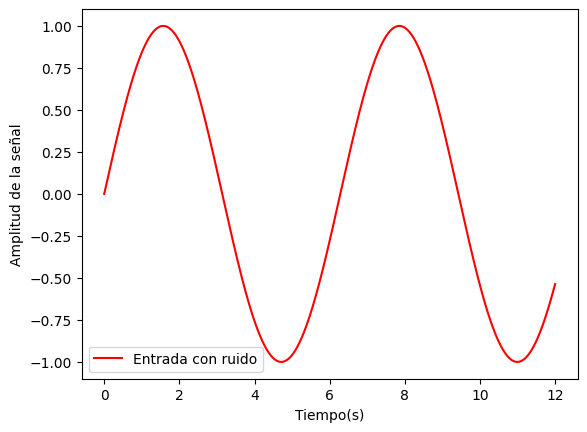

In [5]:

# Salida esperada: señal sin ruido
y = np.sin(t)
plt.plot(t, y, 'r')
plt.legend(["Entrada con ruido", "Salida sin ruido"])
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud de la señal")


In [6]:

# Crear las entradas y la salida para ADALINE
delay = 15
noisy_signal = np.array([X[i:i+delay] for i in range(n_samples-delay)])
print(noisy_signal.shape)
d = y[delay:]

(4985, 15)


In [7]:

# Entrenar el perceptrón
weights, errors = adaline_train(noisy_signal, d, 0.01, 200)
print("Pesos entrenados:", weights)
print("Errores:", errors)

Pesos entrenados: [-0.43044706  4.15189255  2.42221589  1.46216422 -0.18736762 -1.47120737
 -2.08030461 -2.50742207 -2.2585884  -2.4953884  -2.44673205 -1.64414393
  0.16370119  0.91843073  2.49354261  4.46113778]
Errores: [np.float64(212.2613607729192), np.float64(141.30396667061802), np.float64(133.8192404231183), np.float64(125.84890666010466), np.float64(118.30378731261335), np.float64(111.21078771106087), np.float64(104.545678498057), np.float64(98.28276748708998), np.float64(92.39774452837293), np.float64(86.86776081622996), np.float64(81.67135002140917), np.float64(76.78834513096395), np.float64(72.1997997897372), np.float64(67.88791437540766), np.float64(63.835966550132376), np.float64(60.028246019309535), np.float64(56.449993242661286), np.float64(53.087341858164514), np.float64(49.92726459387849), np.float64(46.95752245633188), np.float64(44.16661699694963), np.float64(41.543745470027496), np.float64(39.07875870705663), np.float64(36.7621215428207), np.float64(34.584875638666

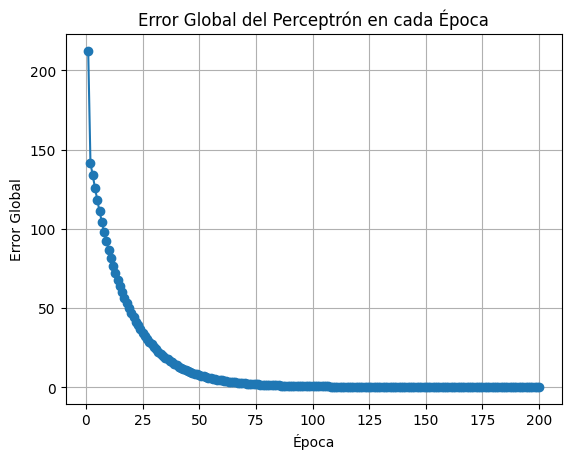

In [8]:

# Graficar el error global en cada época
plt.figure()
plt.plot(range(1, len(errors) + 1), errors, marker='o')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global del Perceptrón en cada Época')
plt.grid(True)


tamaño  (4985,)
tamaños y  (4985,)


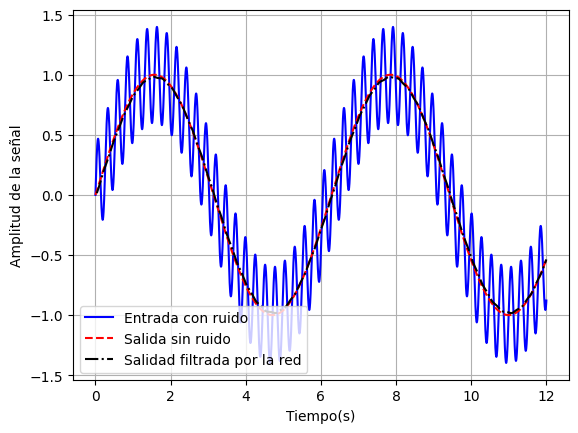

In [9]:

# señal filtrada
prediction = np.zeros(noisy_signal.shape[0])
print("tamaño ", prediction.shape)
i = 0
for xi in noisy_signal:
    # print("prediccion ", i, " ",adaline_predict(xi, weights))
    prediction[i] = adaline_predict(xi, weights)
    i += 1

print("tamaños y ", prediction.shape)
# Mostrar la gráfica
plt.figure()
plt.grid(True)
plt.plot(t, X, 'b')
plt.plot(t, y, '--r')
plt.plot(t[delay:], prediction, '-.k')
plt.legend(["Entrada con ruido", "Salida sin ruido",
           'Salidad filtrada por la red'])
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud de la señal")
plt.show()